# Exploratory Data Analysis

In [52]:
import pandas as pd
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import sys

sns.set_style("darkgrid")
pd.set_option("display.max_columns", 100)

ROOT = Path.cwd().parent.resolve()
DATASET_PATH = ROOT / "dataset" / "Airbnb_Data.csv"

df = pd.read_csv(DATASET_PATH)

df.head()

,id,log_price,property_type,room_type,amenities,accommodates,bathrooms,bed_type,cancellation_policy,cleaning_fee,city,description,first_review,host_has_profile_pic,host_identity_verified,host_response_rate,host_since,instant_bookable,last_review,latitude,longitude,name,neighbourhood,number_of_reviews,review_scores_rating,thumbnail_url,zipcode,bedrooms,beds
0,6901257,5.010635,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",3,1.0,Real Bed,strict,True,NYC,"Beautiful, sunlit brownstone 1-bedroom in the ...",2016-06-18,t,t,NaN,2012-03-26,f,2016-07-18,40.696524,-73.991617,Beautiful brownstone 1-bedroom,Brooklyn Heights,2,100.0,https://a0.muscache.com/im/pictures/6d7cbbf7-c...,11201,1.0,1.0
1,6304928,5.129899,Apartment,Entire home/apt,"{""Wireless Internet"",""Air conditioning"",Kitche...",7,1.0,Real Bed,strict,True,NYC,Enjoy travelling during your stay in Manhattan...,2017-08-05,t,f,100%,2017-06-19,t,2017-09-23,40.766115,-73.989040,Superb 3BR Apt Located Near Times Square,Hell's Kitchen,6,93.0,https://a0.muscache.com/im/pictures/348a55fe-4...,10019,3.0,3.0
2,7919400,4.976734,Apartment,Entire home/apt,"{TV,""Cable TV"",""Wireless Internet"",""Air condit...",5,1.0,Real Bed,moderate,True,NYC,The Oasis comes complete with a full backyard ...,2017-04-30,t,t,100%,2016-10-25,t,2017-09-14,40.808110,-73.943756,The Garden Oasis,Harlem,10,92.0,https://a0.muscache.com/im/pictures/6fae5362-9...,10027,1.0,3.0
3,13418779,6.620073,House,Entire home/apt,"{TV,""Cable TV"",Internet,""Wireless Internet"",Ki...",4,1.0,Real Bed,flexible,True,SF,This light-filled home-away-from-home is super...,NaN,t,t,NaN,2015-04-19,f,NaN,37.772004,-122.431619,Beautiful Flat in the Heart of SF!,Lower Haight,0,NaN,https://a0.muscache.com/im/pictures/72208dad-9...,94117.0,2.0,2.0
4,3808709,4.744932,Apartment,Entire home/apt,"{TV,Internet,""Wireless Internet"",""Air conditio...",2,1.0,Real Bed,moderate,True,DC,"Cool, cozy, and comfortable studio located in ...",2015-05-12,t,t,100%,2015-03-01,t,2017-01-22,38.925627,-77.034596,Great studio in midtown DC,Columbia Heights,4,40.0,NaN,20009,0.0,1.0


In [53]:
df.dtypes

id                          int64
log_price                 float64
property_type                 str
room_type                     str
amenities                     str
accommodates                int64
bathrooms                 float64
bed_type                      str
cancellation_policy           str
cleaning_fee                 bool
city                          str
description                   str
first_review                  str
host_has_profile_pic          str
host_identity_verified        str
host_response_rate            str
host_since                    str
instant_bookable              str
last_review                   str
latitude                  float64
longitude                 float64
name                          str
neighbourhood                 str
number_of_reviews           int64
review_scores_rating      float64
thumbnail_url                 str
zipcode                       str
bedrooms                  float64
beds                      float64
dtype: object

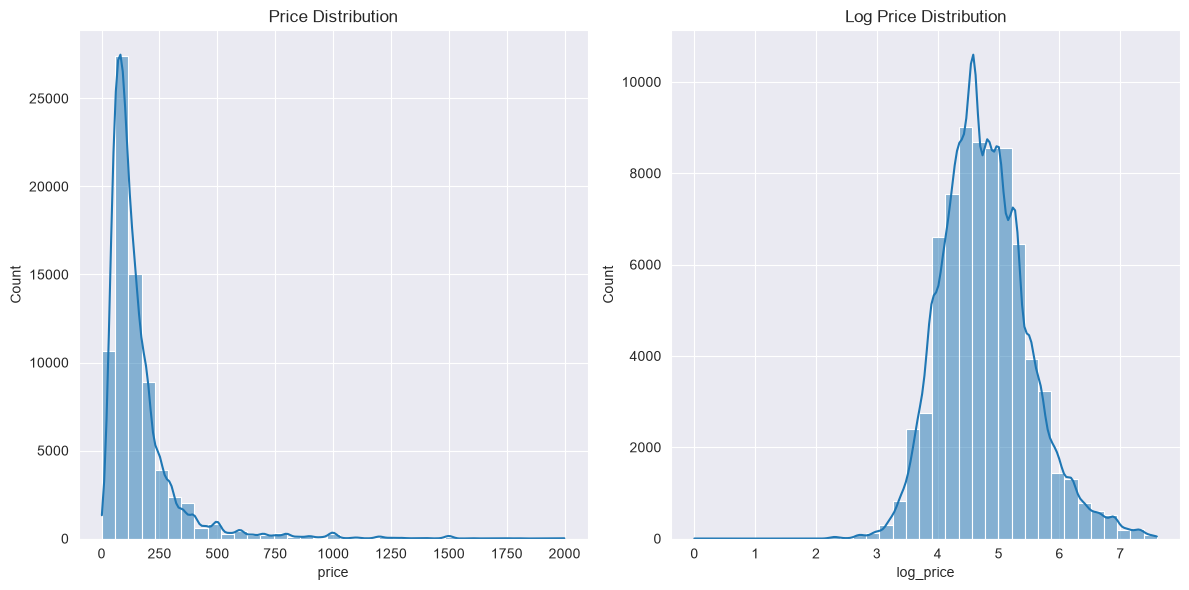

In [54]:
df['price'] = np.exp(df['log_price'])

fig, axes = plt.subplots(ncols=2, nrows=1, figsize=(12, 6))
sns.histplot(data=df, x='price', bins=35, kde=True, ax=axes[0])
sns.histplot(data=df, x='log_price', bins=35, kde=True, ax=axes[1])

axes[0].set_title("Price Distribution")
axes[1].set_title("Log Price Distribution")

plt.tight_layout()
plt.show()

## NaN Report

In [55]:
nan_report = df.isna().mean().sort_values(ascending=False)
nan_report

host_response_rate        0.246913
review_scores_rating      0.225635
first_review              0.214057
last_review               0.213558
thumbnail_url             0.110861
neighbourhood             0.092726
zipcode                   0.013035
bathrooms                 0.002699
host_identity_verified    0.002537
host_since                0.002537
host_has_profile_pic      0.002537
beds                      0.001768
bedrooms                  0.001228
property_type             0.000000
city                      0.000000
description               0.000000
cancellation_policy       0.000000
cleaning_fee              0.000000
bed_type                  0.000000
room_type                 0.000000
amenities                 0.000000
accommodates              0.000000
log_price                 0.000000
id                        0.000000
latitude                  0.000000
instant_bookable          0.000000
name                      0.000000
longitude                 0.000000
number_of_reviews   

In [56]:
(df['last_review'].isna() == df['first_review'].isna()).mean()

np.float64(0.9995007488766849)

In [57]:
(
    (df['host_identity_verified'].isna() == df['host_since'].isna()) &
    (df['host_identity_verified'].isna() == df['host_has_profile_pic'].isna())
).mean()

np.float64(1.0)

In [58]:
df['host_response_rate'] = pd.to_numeric(
    df['host_response_rate'].str.replace("%", "", regex=False),
    errors="coerce"
)

df['host_response_rate'].describe()

count    55812.000000
mean        94.351967
std         16.341817
min          0.000000
25%        100.000000
50%        100.000000
75%        100.000000
max        100.000000
Name: host_response_rate, dtype: float64

In [59]:
df['host_response_rate'].value_counts(normalize=True).head(10)

host_response_rate
100.0    0.774995
90.0     0.040798
80.0     0.019942
0.0      0.015821
50.0     0.010947
70.0     0.009102
99.0     0.008027
67.0     0.007758
98.0     0.007615
94.0     0.007185
Name: proportion, dtype: float64

In [60]:
(df['host_response_rate'].isna() == df['host_identity_verified'].isna()).mean()

np.float64(0.7556233217740956)

In [61]:
pd.crosstab(
    df['host_response_rate'].isna(),
    df['host_identity_verified'].isna()
)

host_identity_verified,False,True
host_response_rate,,
False,55812,0
True,18111,188


In [62]:
cols = nan_report[nan_report > 0].index.tolist()

for col in cols:
    print("\n-------------------------------------")
    print(df.groupby(df[col].isna())['price'].agg(
        ['count', 'mean', 'median']
    ))


-------------------------------------
                    count        mean  median
host_response_rate                           
False               55812  154.705726   110.0
True                18299  177.649489   115.0

-------------------------------------
                      count        mean  median
review_scores_rating                           
False                 57389  147.748297   110.0
True                  16722  203.690767   120.0

-------------------------------------
              count        mean  median
first_review                           
False         58247  147.794393   110.0
True          15864  206.547151   120.0

-------------------------------------
             count        mean  median
last_review                           
False        58284  147.785207   110.0
True         15827  206.718329   120.0

-------------------------------------
               count        mean  median
thumbnail_url                           
False          65895  153.18487

In [63]:
pd.crosstab(
    df['thumbnail_url'].isna(),
    df['first_review'].isna()
)

first_review,False,True
thumbnail_url,,
False,52325,13570
True,5922,2294


In [64]:
df.describe()

,id,log_price,accommodates,bathrooms,host_response_rate,latitude,longitude,number_of_reviews,review_scores_rating,bedrooms,beds,price
count,7.411100e+04,74111.000000,74111.000000,73911.000000,55812.000000,74111.000000,74111.000000,74111.000000,57389.000000,74020.000000,73980.000000,74111.000000
mean,1.126662e+07,4.782069,3.155146,1.235263,94.351967,38.445958,-92.397525,20.900568,94.067365,1.265793,1.710868,160.370849
std,6.081735e+06,0.717394,2.153589,0.582044,16.341817,3.080167,21.705322,37.828641,7.836556,0.852143,1.254142,168.580415
min,3.440000e+02,0.000000,1.000000,0.000000,0.000000,33.338905,-122.511500,0.000000,20.000000,0.000000,0.000000,1.000000
25%,6.261964e+06,4.317488,2.000000,1.000000,100.000000,34.127908,-118.342374,1.000000,92.000000,1.000000,1.000000,75.000000
50%,1.225415e+07,4.709530,2.000000,1.000000,100.000000,40.662138,-76.996965,6.000000,96.000000,1.000000,1.000000,111.000000
75%,1.640226e+07,5.220356,4.000000,1.000000,100.000000,40.746096,-73.954660,23.000000,100.000000,1.000000,2.000000,185.000000
max,2.123090e+07,7.600402,16.000000,8.000000,100.000000,42.390437,-70.985047,605.000000,100.000000,10.000000,18.000000,1999.000000


In [65]:
nan_report

host_response_rate        0.246913
review_scores_rating      0.225635
first_review              0.214057
last_review               0.213558
thumbnail_url             0.110861
neighbourhood             0.092726
zipcode                   0.013035
bathrooms                 0.002699
host_identity_verified    0.002537
host_since                0.002537
host_has_profile_pic      0.002537
beds                      0.001768
bedrooms                  0.001228
property_type             0.000000
city                      0.000000
description               0.000000
cancellation_policy       0.000000
cleaning_fee              0.000000
bed_type                  0.000000
room_type                 0.000000
amenities                 0.000000
accommodates              0.000000
log_price                 0.000000
id                        0.000000
latitude                  0.000000
instant_bookable          0.000000
name                      0.000000
longitude                 0.000000
number_of_reviews   

### Missing Value Analysis Conclusion

During the analysis of missing values, several features with missing values were identified. The highest proportion of missing values was found in:

* `host_response_rate` (~ 24.7%)
* `review_scores_rating` (~ 22.6%)
* `first_review` (~ 21.4%)
* `last_review` (~ 21.3%)
* `thumbnail_url` (~ 11.1%)
* `neighbourhood` (~ 9.3%)

The analysis showed that missing values in the dataset are **not random** and may represent meaningful information.

For *review-related* features (`first_review`, `last_review`), missing values show a strong relationship. In particular `first_review` and `last_review` have almost identical missingness patterns (~99%), suggesting that they represent the same factor: the presence and absence of review history.

Listings without review information have different price distributions compared to listings with reviews. Therefore, missing *review-related* values should not be removed as the absence of reviews itself may be an informative feature.

A similar pattern was observed for `host_response_rate`. The feature contains the largest proportion of missing values, while the available values are highly concentrated around 100%. Since missing values may indicate the absence of host interaction history rather than poor response performance, the missingness may carry predictive information.

The *host-related features* `host_has_profile_pic`, `host_identity_verified` and `host_since` were found to have identical missingness patterns across these features. This indicates that these missing values originate from the same issue. Creating one common flag, such as **host_missing** can be a possible solution.

The `thumbnail_url` feature also showed a meaningful relationship with price. Listings without thumbnail had a different price distribution, suggesting that the absence of an image may describe a specific group of listings rather than a random missing data.

Based on the analysis, the following preprocessing strategy will be considered for the modeling stage:

* Do not remove rows containing missing values, as many missing values appear to have specific predictive meaning.
* `host_response_rate` can be filled with median value, while preserving information through a binary indicator.
* Categorical features with missing values can be filled with **Unknown** value.
* *host-related features* may share one flag for missing values: **host_missing**. `host_since` is a **DateTime** feature and considered to transfrom DateTime information into host age(`days_count`) and fill missing values with median while preserving the missing flag.
* `thumbnail_url` is considered to be transformed into a binary feature.

----

## Duplicate Inspection

In [66]:
df_copy = df.drop(columns='id')

df_copy.duplicated().sum()

np.int64(0)

### Duplicate Inspection Conclusion

There are not duplicates in the dataset